In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [91]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\Export1.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17553 entries, 0 to 17552
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  17553 non-null  str  
 1   Message  17553 non-null  str  
 2   Status   17553 non-null  str  
dtypes: str(3)
memory usage: 411.5 KB


In [92]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252521    9083
0x252513    5346
0x252501    1465
0x252511    1417
0x252514     242
Name: count, dtype: int64

In [93]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17553 entries, 0 to 17552
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  17553 non-null  str  
 1   Message  17553 non-null  str  
 2   Status   17553 non-null  str  
 3   Headers  17553 non-null  str  
dtypes: str(4)
memory usage: 548.7 KB


Odometer

In [94]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 5588 entries, 2 to 17469
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             5588 non-null   str  
 1   Message             5588 non-null   str  
 2   Status              5588 non-null   str  
 3   Headers             5588 non-null   str  
 4   Odometer in meters  5588 non-null   int64
 5   Date                5588 non-null   str  
 6   Raw data            5588 non-null   str  
dtypes: int64(1), str(6)
memory usage: 349.2 KB
None


260711135529 -> 0 -> 0.0 -> 0x252513005900030869487060207049003C38402D00000060500000000000640000000000000000FFFFFFFFFFFF00D5000000001026071113552900407F445C0D99C2A5C85D400000006C03242337FFFFFF000021FFFFFFFFFF
260711135702 -> 1 -> 0.0 -> 0x252514005900150869487060207049003C38402D000000644B0000000700644100000000000000FFFFFFFFFFFF16D500000000102607111357029A999D41888995C2948F2E410000015303442195FFFFFF0000240000FFFFFF
260711135830 -> 2 -> 0.0 -> 0x252513005900040869487060207049003C38402D000000644C0000000700644100000000000000FFFFFFFFFFFF00D500000000102607111358309A999D41888995C2948F2E410000015303522175FFFFFF0000250000FFFFFF
260711152523 -> 3 -> 0.0 -> 0x252513005900050869487060207049003C38402D000000644D0000000000644000000000000000FFFFFFFFFFFF00D500000000622607111525239A999D41888995C2948F2E410000015303792657FFFFFF000028FFFFFFFFFF
260711152629 -> 4 -> 0.0 -> 0x252513005900060869487060207049003C38402D00000064000000000000644000000000000000FFFFFFFFFFFF00D5000000006226071115262982DC00650C00F03475

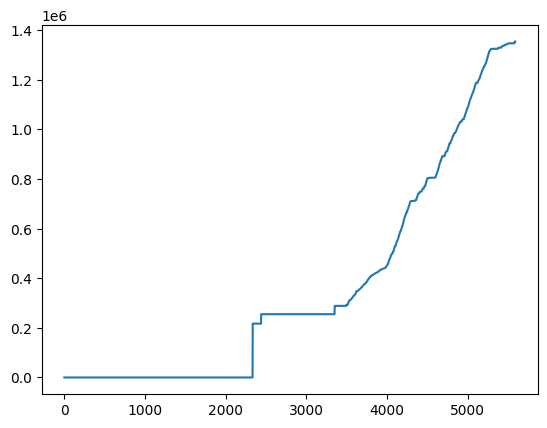

In [95]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [108]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_aux_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        speed.append(int(unit_aux.iloc[i,2][142:145]))  
        date.append(unit_aux.iloc[i,2][106:118])
        raw.append(unit_aux.iloc[i,2])   
    except:
        pass

unit_aux_speed['Speed']=speed
unit_aux_speed['Date']=date
unit_aux_speed['Raw data']=raw

unit=unit_aux_speed.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 4917 entries, 0 to 4674
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Speed     4917 non-null   int64
 1   Date      4917 non-null   str  
 2   Raw data  4917 non-null   str  
dtypes: int64(1), str(2)
memory usage: 153.7 KB
None


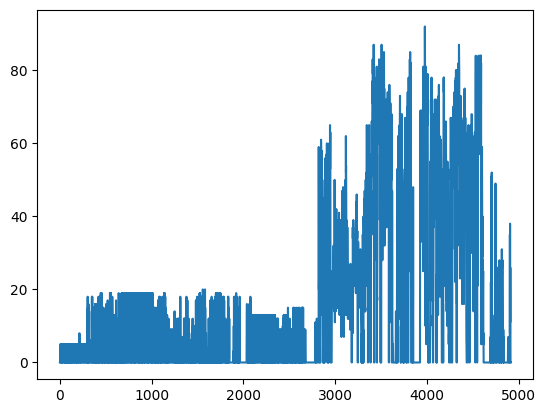

In [110]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])

plt.plot(x_axis,y_axis)

Satellites

In [111]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

for i in range(0,unit.shape[0]):
    if unit.iloc[i,5]>0:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

128 -> 2026-07-11 22:11:02.106 -> 0 -> 0x252513005901990869487060207049003C38402D00000033800000000000644000000000000000FFFFFFFFFFFF00D5000000000026071122105882DC00650C091C337578002A0012016703912732FFFFFF000024FFFFFFFFFF
128 -> 2026-07-11 22:17:41.667 -> 0 -> 0x2525130059019F0869487060207049003C38402D00000025800000000000644000000000000000FFFFFFFFFFFF00D5000000000026071122165882DC00650C091C337578002A0000000003912734FFFFFF000024FFFFFFFFFF
128 -> 2026-07-11 22:18:04.916 -> 0 -> 0x252513005901A00869487060207049003C38402D00000000800000000000644000000000000000FFFFFFFFFFFF00D5000000000026071122175882DC00650C091C337578002A0000000003912793FFFFFF000024FFFFFFFFFF
128 -> 2026-07-11 22:56:27.597 -> 13 -> 0x252513005901C70869487060207049003C38402D00000064CD0000000000644000000000000000FFFFFFFFFFFF00D500000000002607112256589A999D41888995C2948F2E410000015303902799FFFFFF000022FFFFFFFFFF252513005901C80869487060207049003C38402D00000000800000000000644000000000000000FFFFFFFFFFFF0080000000000026071122575882DC

Coordinates

In [112]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
latitude=[]
longitude=[]
speed=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    latitude.append(unit_aux.iloc[i,2][135:142])
    longitude.append(unit_aux.iloc[i,2][126:134])
    speed.append(int(unit_aux.iloc[i,2][142:145],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Latitude']=latitude
unit_aux['Longitude']=longitude
unit_aux['Raw data']=raw
unit_aux['Date']=date
unit_aux['Speed']=speed

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

for i in range(0,unit.shape[0]):
    num_events=num_events+1
    print(unit.iloc[i,4],'->', unit.iloc[i,5], '->',unit.iloc[i,8],unit.iloc[i,7])

<class 'pandas.DataFrame'>
Index: 5588 entries, 2 to 17469
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Created    5588 non-null   str  
 1   Message    5588 non-null   str  
 2   Status     5588 non-null   str  
 3   Headers    5588 non-null   str  
 4   Latitude   5588 non-null   str  
 5   Longitude  5588 non-null   str  
 6   Raw data   5588 non-null   str  
 7   Date       5588 non-null   str  
 8   Speed      5588 non-null   int64
dtypes: int64(1), str(8)
memory usage: 436.6 KB
None
5C85D40 -> 5C0D99C2 -> 0 260711135529
48F2E41 -> 888995C2 -> 0 260711135702
48F2E41 -> 888995C2 -> 0 260711135830
48F2E41 -> 888995C2 -> 0 260711152523
5350057 -> 0C00F034 -> 14 260711152629
53500E7 -> 0C00F066 -> 5 260711152728
53500E7 -> 0C00F066 -> 5 260711152828
53500E7 -> 0C00F066 -> 5 260711152929
53500E7 -> 0C00F066 -> 5 260711153029
53500E7 -> 0C00F066 -> 5 260711153129
53500E7 -> 0C00F066 -> 5 260711153229
48F2E41 -> 888995C2